# Question 3: Histogram Equalization on the Runway Image

Write a **custom histogram equalization function** (without using `cv.equalizeHist()`) and apply it to the runway image.

**Theory:**  
Histogram equalization redistributes pixel intensities so that the output histogram is approximately uniform. This is done using the **Cumulative Distribution Function (CDF)** of the image histogram as the intensity transform:

$$s_k = (L-1) \cdot \frac{CDF(r_k)}{M \times N}$$

where $L=256$, $M \times N$ is the total number of pixels, and $r_k$ is the input intensity level.

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## Load the Runway Image

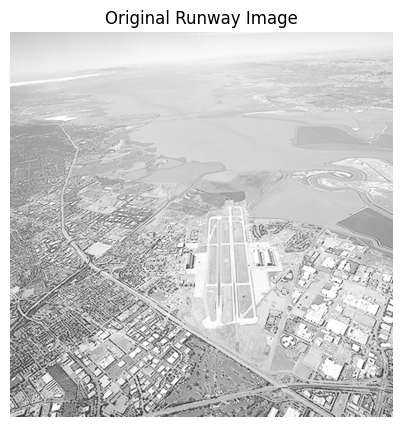

Image shape: (769, 765)
Min intensity: 0   Max intensity: 255


In [2]:
f = cv.imread('images/runway.png', cv.IMREAD_GRAYSCALE)
assert f is not None, "Could not load runway.png. Check the images/ folder."

plt.figure(figsize=(6, 5))
plt.imshow(f, cmap='gray', vmin=0, vmax=255)
plt.title('Original Runway Image')
plt.axis('off')
plt.show()
print('Image shape:', f.shape)
print('Min intensity:', f.min(), '  Max intensity:', f.max())

## Step 1 — Compute the Histogram

Count how many pixels exist at each intensity level (0–255).

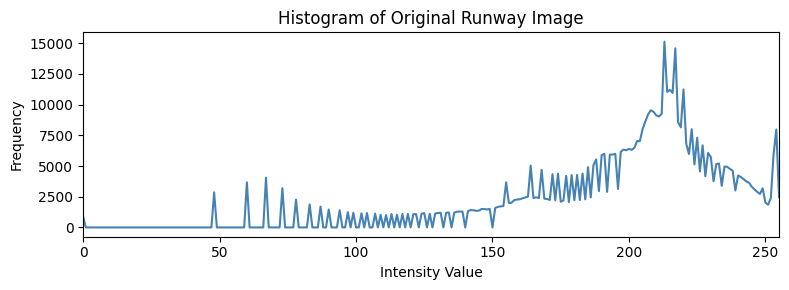

Total pixels: 769 x 765 = 588285


In [3]:
M, N = f.shape          # image dimensions
L = 256                 # number of intensity levels

# Compute histogram using NumPy
hist, bins = np.histogram(f.ravel(), bins=L, range=[0, 256])

plt.figure(figsize=(8, 3))
plt.plot(hist, color='steelblue')
plt.title('Histogram of Original Runway Image')
plt.xlabel('Intensity Value')
plt.ylabel('Frequency')
plt.xlim([0, 255])
plt.tight_layout()
plt.show()

print(f'Total pixels: {M} x {N} = {M*N}')

## Step 2 — Compute the CDF

The CDF is the cumulative sum of the histogram — it tells us how many pixels have intensity **≤ k** for each level k.

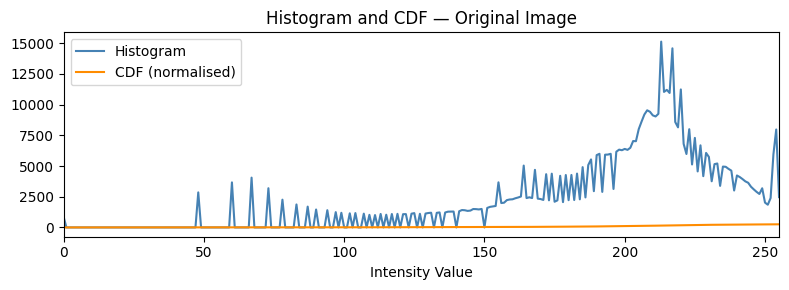

In [4]:
# Cumulative sum of the histogram
cdf = hist.cumsum()

# Normalise CDF for plotting (scale to [0, 255])
cdf_normalised = cdf * 255 / cdf[-1]

plt.figure(figsize=(8, 3))
plt.plot(hist, color='steelblue', label='Histogram')
plt.plot(cdf_normalised, color='darkorange', label='CDF (normalised)')
plt.title('Histogram and CDF — Original Image')
plt.xlabel('Intensity Value')
plt.xlim([0, 255])
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

## Step 3 — Build the Equalization Transform (LUT)

The equalization transform maps each input intensity $r_k$ to:

$$s_k = \left\lfloor \frac{L-1}{M \times N} \cdot CDF(r_k) \right\rfloor$$

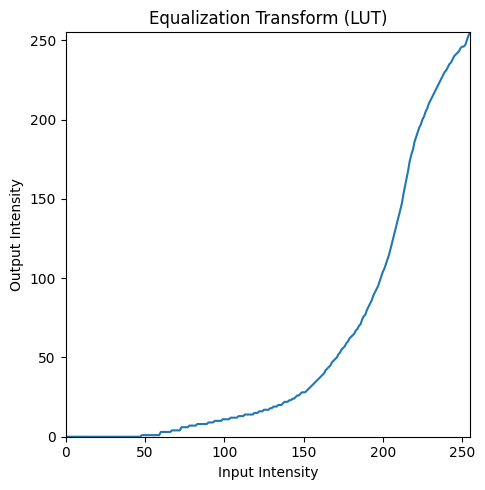

In [5]:
# Build the LUT from the CDF
lut = np.array([(L - 1) / (M * N) * cdf[i] for i in range(L)], dtype=np.uint8)

plt.figure(figsize=(5, 5))
plt.plot(lut)
plt.title('Equalization Transform (LUT)')
plt.xlabel('Input Intensity')
plt.ylabel('Output Intensity')
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.gca().set_aspect('equal')
plt.tight_layout()
plt.show()

## Step 4 — Define the Custom Equalization Function

Wrapping the above steps into a reusable function.

In [8]:
def equalize_histogram(image):
    """
    Custom histogram equalization for a grayscale image.
    
    Parameters
    ----------
    image : np.ndarray
        Input grayscale image (uint8, shape HxW).

    Returns
    -------
    equalized : np.ndarray
        Histogram-equalized grayscale image (uint8).
    lut : np.ndarray
        The 256-entry look-up table used for the transform.
    """
    M, N = image.shape
    L = 256

    # Step 1: Compute histogram
    hist, _ = np.histogram(image.ravel(), bins=L, range=[0, 256])

    # Step 2: Compute CDF
    cdf = hist.cumsum()

    # Step 3: Build LUT using the equalization formula
    lut = np.array([(L - 1) / (M * N) * cdf[i] for i in range(L)], dtype=np.uint8)

    # Step 4: Apply LUT to image using NumPy indexing
    equalized = lut[image]

    return equalized, lut

## Step 5 — Apply to Runway Image

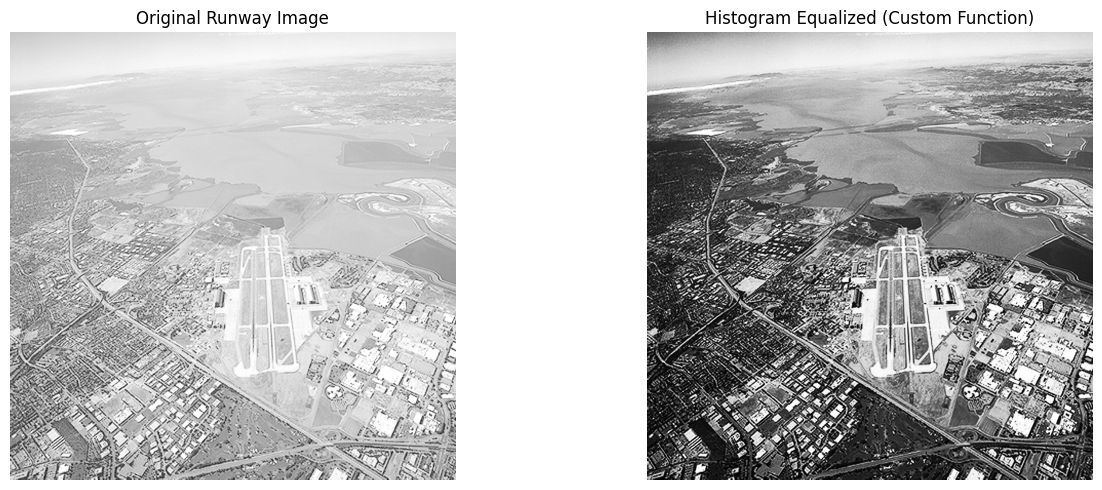

In [9]:
g, lut = equalize_histogram(f)

# Display original vs equalized
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(f, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original Runway Image')
axes[0].axis('off')

axes[1].imshow(g, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Histogram Equalized (Custom Function)')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('output/q3_equalized.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 6 — Compare Histograms Before and After

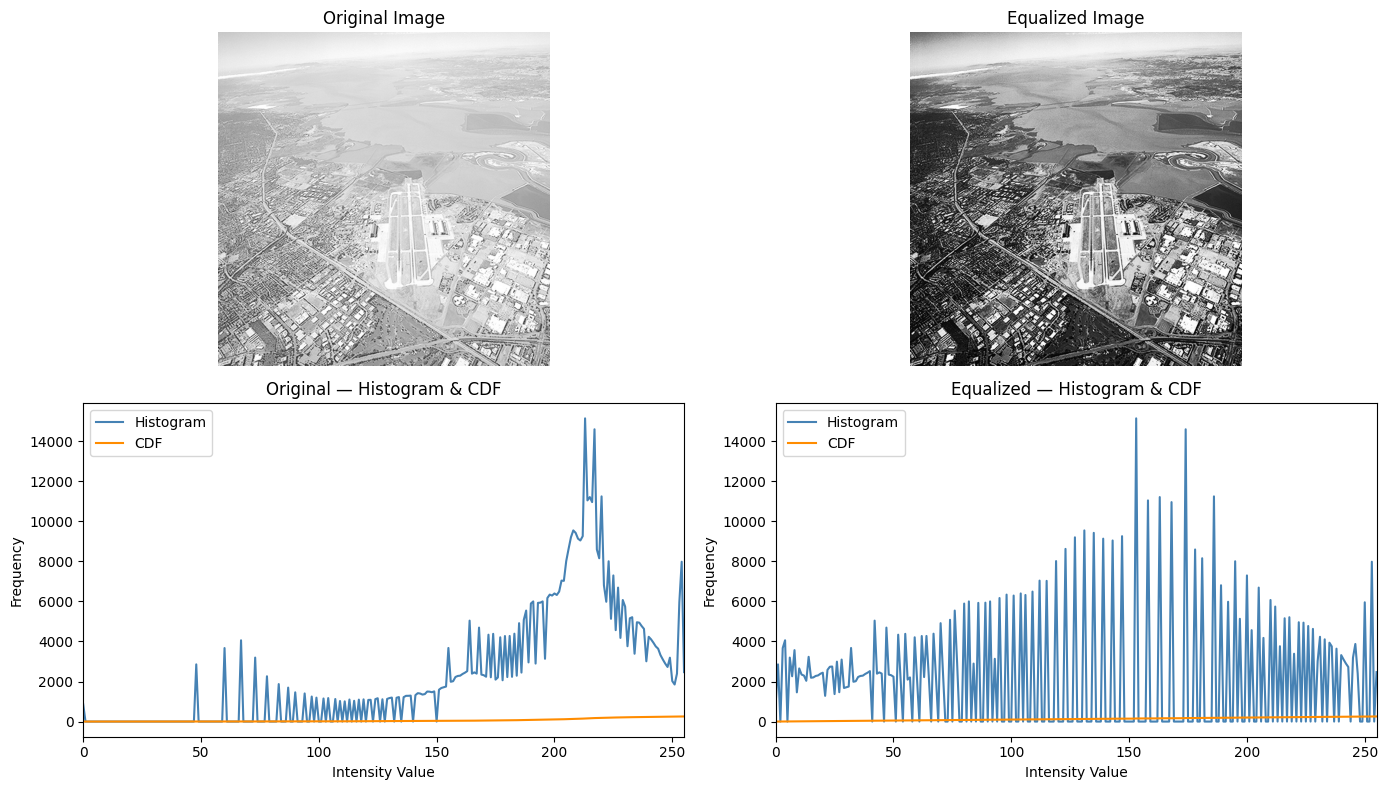

In [10]:
hist_orig, _ = np.histogram(f.ravel(), 256, [0, 256])
hist_eq,   _ = np.histogram(g.ravel(), 256, [0, 256])

cdf_orig = hist_orig.cumsum()
cdf_eq   = hist_eq.cumsum()
cdf_orig_norm = cdf_orig * 255 / cdf_orig[-1]
cdf_eq_norm   = cdf_eq   * 255 / cdf_eq[-1]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].imshow(f, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

axes[0, 1].imshow(g, cmap='gray', vmin=0, vmax=255)
axes[0, 1].set_title('Equalized Image')
axes[0, 1].axis('off')

axes[1, 0].plot(hist_orig, color='steelblue', label='Histogram')
axes[1, 0].plot(cdf_orig_norm, color='darkorange', label='CDF')
axes[1, 0].set_title('Original — Histogram & CDF')
axes[1, 0].set_xlabel('Intensity Value')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_xlim([0, 255])
axes[1, 0].legend(loc='upper left')

axes[1, 1].plot(hist_eq, color='steelblue', label='Histogram')
axes[1, 1].plot(cdf_eq_norm, color='darkorange', label='CDF')
axes[1, 1].set_title('Equalized — Histogram & CDF')
axes[1, 1].set_xlabel('Intensity Value')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_xlim([0, 255])
axes[1, 1].legend(loc='upper left')

plt.tight_layout()
plt.savefig('output/q3_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 7 — Verify Against OpenCV's Built-in `cv.equalizeHist()`

Max pixel difference vs cv.equalizeHist(): 1
Mean pixel difference: 0.37949973227262296


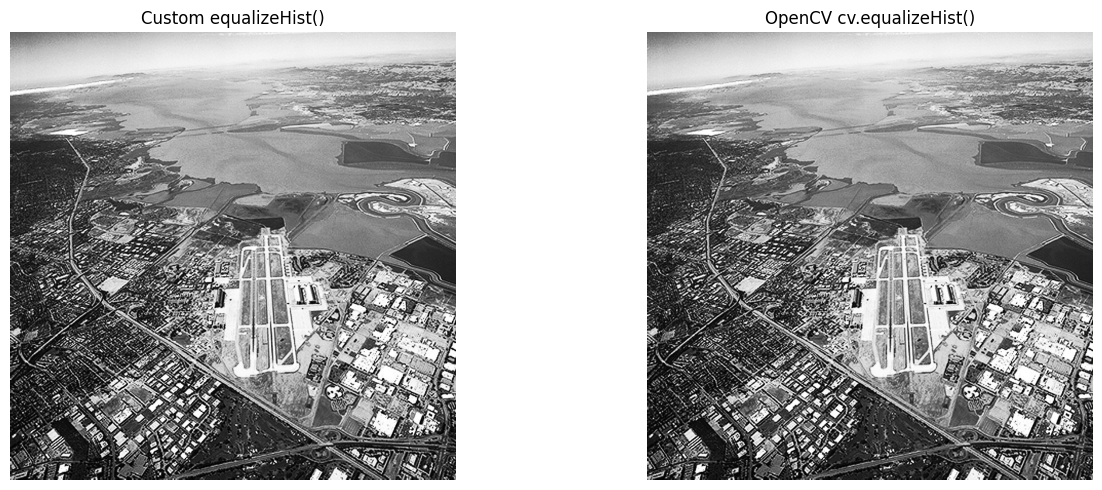

In [11]:
g_cv = cv.equalizeHist(f)

# Check how close our result is to OpenCV's
diff = np.abs(g.astype(int) - g_cv.astype(int))
print('Max pixel difference vs cv.equalizeHist():', diff.max())
print('Mean pixel difference:', diff.mean())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(g, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Custom equalizeHist()')
axes[0].axis('off')

axes[1].imshow(g_cv, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('OpenCV cv.equalizeHist()')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('output/q3_custom_vs_opencv.png', dpi=150, bbox_inches='tight')
plt.show()